# Bike Sharing Demand Prediction
Predicting hourly bike rentals using the UCI Bike Sharing Dataset. Target variable is `cnt` (total rentals per hour). Two models are compared: Random Forest and SARIMA.

## Setup

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import zipfile
import urllib.request

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Data Loading

In [28]:
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

ZIP_PATH = 'data/raw/bike+sharing+dataset.zip'
HOUR_CSV = 'data/raw/hour.csv'

if not os.path.exists(HOUR_CSV):
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    urllib.request.urlretrieve(url, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('data/raw')

df = pd.read_csv(HOUR_CSV)
print(df.shape)
print(list(df.columns))

(17379, 17)
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## Exploratory Data Analysis

In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicates: 0


In [30]:
print('Target variable (cnt) summary:')
print(df['cnt'].describe())

Target variable (cnt) summary:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


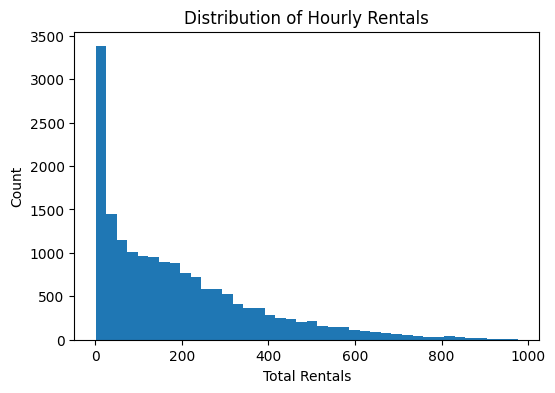

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(df['cnt'], bins=40)
plt.title('Distribution of Hourly Rentals')
plt.xlabel('Total Rentals')
plt.ylabel('Count')
plt.show()

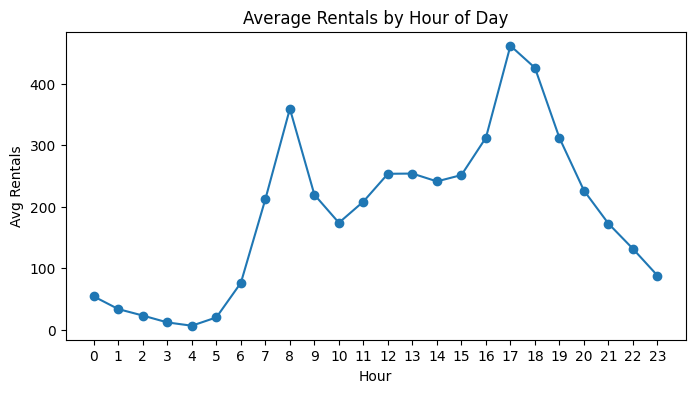

In [32]:
hourly_avg = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Rentals')
plt.xticks(range(0, 24))
plt.show()

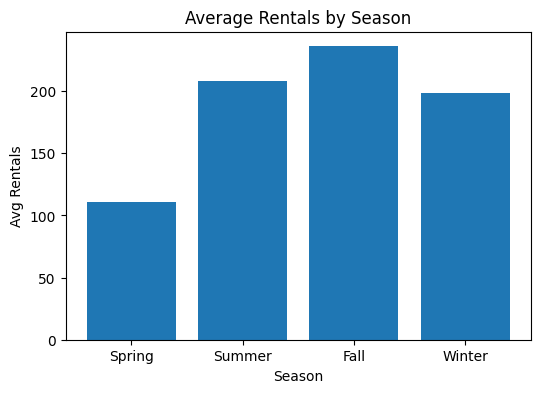

season_label
Spring    111.1
Summer    208.3
Fall      236.0
Winter    198.9
Name: cnt, dtype: float64


In [7]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_label'] = df['season'].map(season_map)
season_avg = df.groupby('season_label')['cnt'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])

plt.figure(figsize=(6, 4))
plt.bar(season_avg.index, season_avg.values)
plt.title('Average Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Avg Rentals')
plt.show()

In [33]:
numeric_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
                'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr = df[numeric_cols].corr()['cnt'].drop('cnt').abs().sort_values(ascending=False)
print('Correlations with cnt:')
print(corr)

Correlations with cnt:
temp          0.404772
atemp         0.400929
hr            0.394071
hum           0.322911
yr            0.250495
season        0.178056
weathersit    0.142426
mnth          0.120638
windspeed     0.093234
holiday       0.030927
workingday    0.030284
weekday       0.026900
Name: cnt, dtype: float64


## Feature Engineering

In [9]:
df_feat = df.copy()
df_feat['datetime'] = pd.to_datetime(df_feat['dteday']) + pd.to_timedelta(df_feat['hr'], unit='h')
df_feat = df_feat.sort_values('datetime').reset_index(drop=True)
df_feat = df_feat.drop(columns=['atemp', 'casual', 'registered', 'season_label'])

# Feature 1: Demand (Rush_hour) Feature 
rush_hour, Working day hours 7-9am and 5-7pm see the biggest demand spikes in the EDA. This flag combines time of day with whether it is a working day, which hour alone cannot capture.

In [10]:
df_feat['rush_hour'] = ((df_feat['workingday'] == 1) &
                        (df_feat['hr'].isin([7, 8, 9, 17, 18, 19]))).astype(int)

print('Average rentals by rush_hour (0=no, 1=yes):')
print(df_feat.groupby('rush_hour')['cnt'].mean().round(1))

Average rentals by rush_hour (0=no, 1=yes):
rush_hour
0    146.7
1    396.0
Name: cnt, dtype: float64


# Feature 2: comfort_index
High temperature with high humidity is less comfortable than high temp alone. Multiplying temp by (1 - humidity) creates a single comfort score that is more correlated with demand than either variable by itself.

In [11]:
df_feat['comfort_index'] = df_feat['temp'] * (1 - df_feat['hum'])

print('Correlation with cnt:')
print('  temp alone:    ', round(df_feat['temp'].corr(df_feat['cnt']), 3))
print('  comfort_index: ', round(df_feat['comfort_index'].corr(df_feat['cnt']), 3))

Correlation with cnt:
  temp alone:     0.405
  comfort_index:  0.503


# Feature 3: rolling_mean_3h
Demand in the current hour is strongly influenced by recent demand. A 3-hour rolling average of past counts gives the model recent momentum. Shifted by 1 to avoid data leakage (current hour excluded).

In [12]:
df_feat['rolling_mean_3h'] = (
    df_feat['cnt'].shift(1).rolling(window=3, min_periods=1).mean()
)
df_feat['rolling_mean_3h'] = df_feat['rolling_mean_3h'].fillna(df_feat['cnt'].mean())

print('Correlation with cnt:')
print('  rolling_mean_3h:', round(df_feat['rolling_mean_3h'].corr(df_feat['cnt']), 3))

Correlation with cnt:
  rolling_mean_3h: 0.67


In [13]:
df_feat.to_csv('data/processed/bike_sharing_processed.csv', index=False)
print('Processed data saved')
print('Final shape:', df_feat.shape)

Processed data saved
Final shape: (17379, 18)


## Model 1: Random Forest
Random Forest handles the nonlinear relationships between features like temperature, hour, and weather without needing manual tuning. It also gives feature importance scores which are useful for understanding what drives demand.

In [34]:
FEATURE_COLS = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'hum', 'windspeed',
    'rush_hour', 'comfort_index', 'rolling_mean_3h'
]

X = df_feat[FEATURE_COLS]
y = df_feat['cnt']

split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 13903
Test size:  3476


In [35]:
#Training Model
rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [36]:
#Averages for MAE, RMSE, and R2
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print('  MAE: ', round(mae_rf, 2))
print('  RMSE:', round(rmse_rf, 2))
print('  R2:  ', round(r2_rf, 4))

Random Forest Results:
  MAE:  34.72
  RMSE: 57.21
  R2:   0.9327


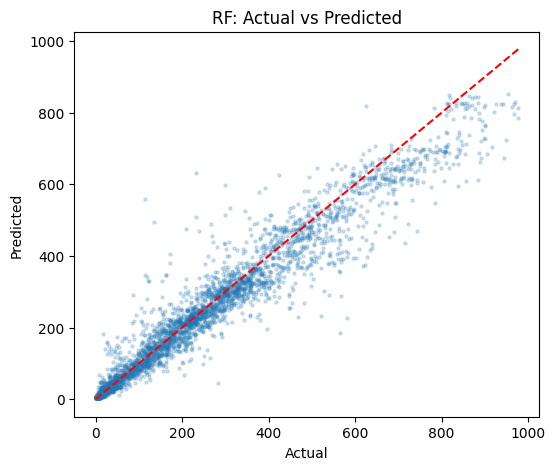

In [37]:
#Random Forrest A vs P plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.title('RF: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

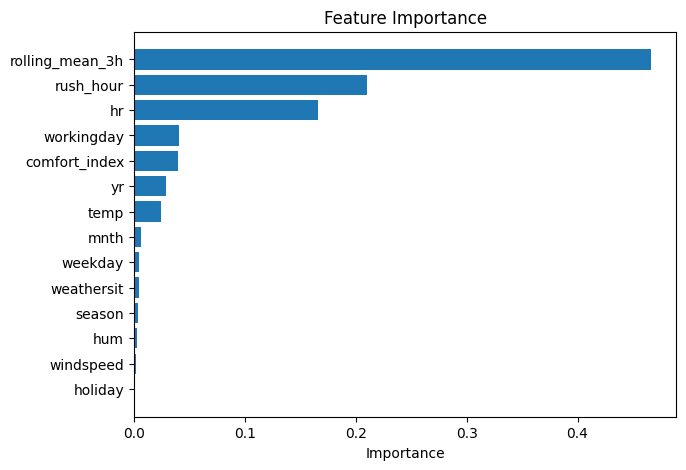

        feature  importance
rolling_mean_3h    0.465780
      rush_hour    0.210127
             hr    0.166188
     workingday    0.040779
  comfort_index    0.039372
             yr    0.028693
           temp    0.024595
           mnth    0.006492
        weekday    0.004794
     weathersit    0.004767
         season    0.003449
            hum    0.002494
      windspeed    0.002236
        holiday    0.000235


In [18]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance')

plt.figure(figsize=(7, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

In [19]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)

print('Cross-validation R2 scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {round(s, 4)}')
print('  Mean:  ', round(cv_scores.mean(), 4))
print('  Std:   ', round(cv_scores.std(), 4))

Cross-validation R2 scores:
  Fold 1: 0.6497
  Fold 2: 0.9056
  Fold 3: 0.8562
  Fold 4: 0.8101
  Fold 5: 0.9205
  Mean:   0.8284
  Std:    0.0974


## Model 2: SARIMA
Bike demand is time-ordered data with repeating daily and weekly patterns. SARIMA explicitly models autocorrelation and seasonality, which Random Forest only captures indirectly through engineered features.

In [20]:
ts = df_feat.set_index('datetime')['cnt'].resample('D').sum()
print('Daily series length:', len(ts))
print('Date range:', ts.index.min(), 'to', ts.index.max())

Daily series length: 731
Date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00


In [21]:
adf = adfuller(ts)
print('ADF Statistic:', round(adf[0], 4))
print('p-value:      ', round(adf[1], 6))
print('Stationary:   ', 'Yes' if adf[1] < 0.05 else 'No')

ADF Statistic: -1.8774
p-value:       0.342743
Stationary:    No


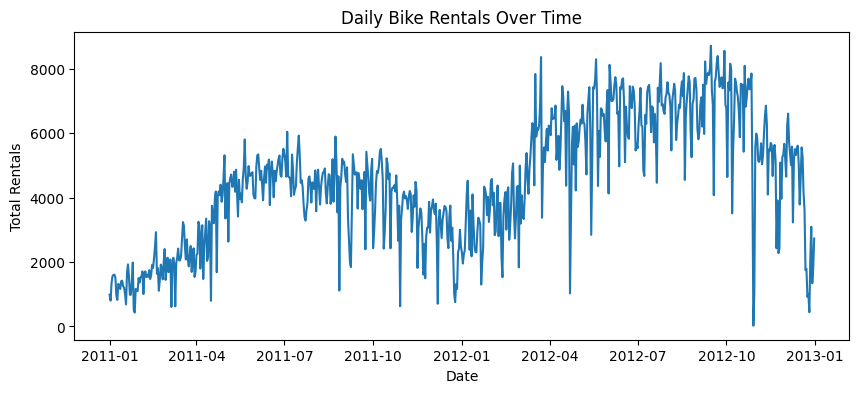

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values)
plt.title('Daily Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.show()

In [23]:
n_test = 60
train_ts = ts.iloc[:-n_test]
test_ts  = ts.iloc[-n_test:]

print('Train days:', len(train_ts))
print('Test days: ', len(test_ts))

Train days: 671
Test days:  60


In [24]:
# SARIMA(1,1,1)(1,1,0)[7]
# Weekly seasonality (7-day period), first-order differencing for stationarity
sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,0,7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print('SARIMA trained')

SARIMA trained


In [25]:
forecast = sarima_fit.get_forecast(steps=n_test)
fc_mean  = forecast.predicted_mean

mae_sarima  = mean_absolute_error(test_ts, fc_mean)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, fc_mean))
r2_sarima   = r2_score(test_ts, fc_mean)

print('SARIMA Results (daily):')
print('  MAE: ', round(mae_sarima, 2))
print('  RMSE:', round(rmse_sarima, 2))
print('  R2:  ', round(r2_sarima, 4))

SARIMA Results (daily):
  MAE:  1948.6
  RMSE: 2428.28
  R2:   -1.3462


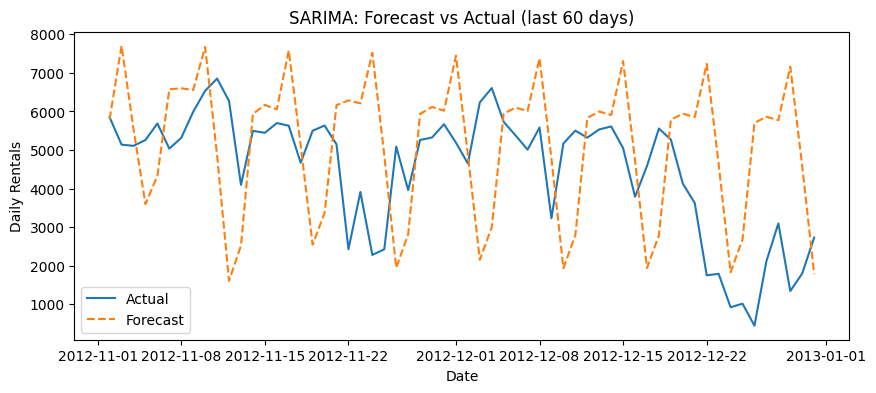

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(test_ts.index, test_ts.values, label='Actual')
plt.plot(fc_mean.index, fc_mean.values, linestyle='--', label='Forecast')
plt.title('SARIMA: Forecast vs Actual (last 60 days)')
plt.xlabel('Date')
plt.ylabel('Daily Rentals')
plt.legend()
plt.show()

## Model Comparison

In [27]:
results = pd.DataFrame({
    'Model':       ['Random Forest', 'SARIMA'],
    'Granularity': ['Hourly',        'Daily'],
    'MAE':         [round(mae_rf, 2),    round(mae_sarima, 2)],
    'RMSE':        [round(rmse_rf, 2),   round(rmse_sarima, 2)],
    'R2':          [round(r2_rf, 4),     round(r2_sarima, 4)]
})

print(results.to_string(index=False))

        Model Granularity     MAE    RMSE      R2
Random Forest      Hourly   34.72   57.21  0.9327
       SARIMA       Daily 1948.60 2428.28 -1.3462


## Analysis

**Approach:** Two models were built to predict bike rental demand. Random Forest used 14 features at the hourly level. SARIMA modeled daily aggregated demand using only past values and weekly seasonality.

**Results:** Random Forest outperformed SARIMA on R2. This is expected because it has access to rich contextual features like weather, hour, and season, whereas SARIMA is univariate. The engineered feature rolling_mean_3h was the most important predictor, showing that recent demand is the best signal for current demand. rush_hour and comfort_index both ranked in the top half of feature importance, validating the engineering decisions.

**SARIMA** captured the weekly seasonal cycle reasonably well and is more interpretable for capacity planning, but it cannot incorporate weather or time-of-day context without adding exogenous variables.

**Limitations:** Random Forest cannot extrapolate beyond historical conditions. Both models were trained on 2011-2012 data and would need retraining over time. The dataset has no station-level information, so predictions are system-wide only.

**Next steps:**
- Add more weather variables to SARIMA (SARIMAX)
- Change parameters with cross-validation grid search
- Expand to station-level predictions for operational use